<a href="https://colab.research.google.com/github/sauravv-kunwar/100-days-of-ML/blob/main/Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Support Vector Machines (SVM)

Support Vector Machines (SVMs) are powerful supervised learning models used for classification and regression tasks. The core idea behind SVMs is to find an optimal hyperplane that best separates data points of different classes in a high-dimensional space.

### Key Concepts:

*   **Hyperplane**: A decision boundary that separates data points of different classes.
*   **Support Vectors**: The data points closest to the hyperplane. These points are crucial in defining the orientation and position of the hyperplane.
*   **Margin**: The distance between the hyperplane and the nearest data point from either class. SVM aims to maximize this margin.

### Mathematical Formulation (Linear SVM for Binary Classification):

The hyperplane can be represented by the equation:

$$w \cdot x - b = 0$$

where:
*   $w$ is the normal vector to the hyperplane.
*   $x$ is a data point.
*   $b$ is the bias (or intercept).

For a linearly separable dataset, the classification rule is:

$$f(x) = \text{sign}(w \cdot x - b)$$

The objective of a hard-margin SVM is to minimize $||w||$ subject to the constraints:

$$y_i(w \cdot x_i - b) \ge 1 \quad \text{for all } i$$

where $y_i$ is the class label (either +1 or -1) for data point $x_i$.

### Soft Margin SVM:

To handle non-linearly separable data and outliers, a "soft margin" SVM is introduced, allowing some misclassifications. This involves introducing slack variables $\xi_i \ge 0$:

$$\min_{w,b,\xi} \frac{1}{2}||w||^2 + C\sum_{i=1}^{n} \xi_i$$

subject to:

$$y_i(w \cdot x_i - b) \ge 1 - \xi_i \quad \text{for all } i$$

where $C > 0$ is a regularization parameter that controls the trade-off between maximizing the margin and minimizing the classification error.

### Kernel Trick:

For non-linear separation, SVMs use the "kernel trick" to map data into a higher-dimensional feature space where a linear separation might be possible. Common kernel functions include:

*   **Linear Kernel**: $K(x_i, x_j) = x_i \cdot x_j$
*   **Polynomial Kernel**: $K(x_i, x_j) = (\gamma x_i \cdot x_j + r)^d$
*   **Radial Basis Function (RBF) / Gaussian Kernel**: $K(x_i, x_j) = e^{-\gamma ||x_i - x_j||^2}$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes._axes import _log as matplotlib_axes_logger
from mpl_toolkits import mplot3d
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

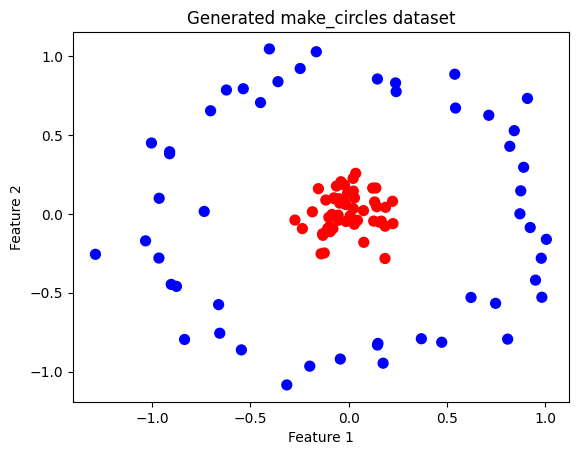

In [16]:
from sklearn.datasets import make_circles

X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')
plt.title('Generated make_circles dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

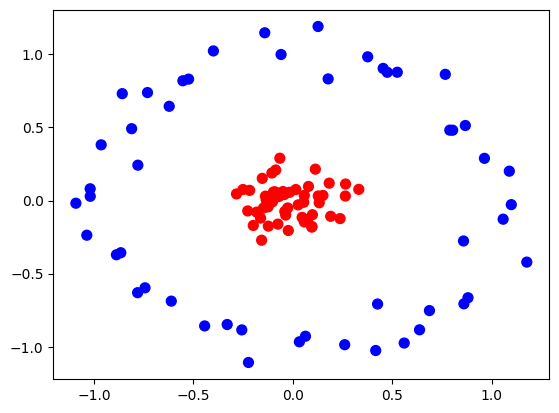

In [17]:
from sklearn.datasets import make_circles
X, y = make_circles(100, factor=.1, noise=.1)

plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='bwr')

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20)

In [19]:
classifier = SVC(kernel="linear")
classifier.fit(X_train, y_train.ravel())
y_pred = classifier.predict(X_test)

In [20]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)


0.45

In [21]:
zero_one_colourmap = ListedColormap(('blue', 'red'))
def plot_decision_boundary(X, y, clf):
    X_set, y_set = X, y
    X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1,
                                 stop = X_set[:, 0].max() + 1,
                                 step = 0.01),
                       np.arange(start = X_set[:, 1].min() - 1,
                                 stop = X_set[:, 1].max() + 1,
                                 step = 0.01))

    plt.contourf(X1, X2, clf.predict(np.array([X1.ravel(),
                                             X2.ravel()]).T).reshape(X1.shape),
               alpha = 0.75,
               cmap = zero_one_colourmap)
    plt.xlim(X1.min(), X1.max())
    plt.ylim(X2.min(), X2.max())
    for i, j in enumerate(np.unique(y_set)):
        plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = (zero_one_colourmap)(i), label = j)
    plt.title('SVM Decision Boundary')
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.legend()
    return plt.show()

/tmp/ipykernel_9614/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


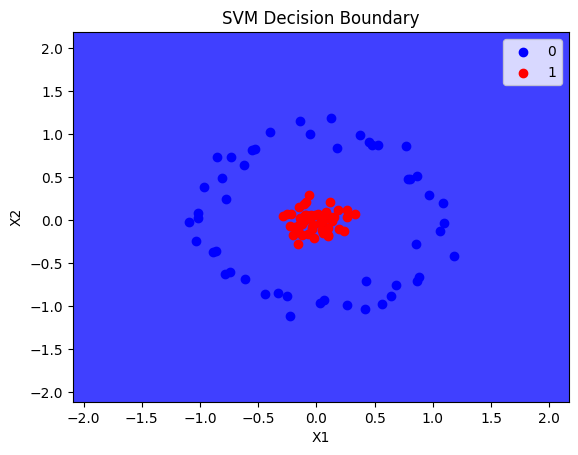

In [22]:
plot_decision_boundary(X, y, classifier)

In [23]:
def plot_3d_plot(X, y):
    r = np.exp(-(X ** 2).sum(1))
    ax = plt.subplot(projection='3d')
    ax.scatter3D(X[:, 0], X[:, 1], r, c=y, s=100, cmap='bwr')
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_zlabel('y')
    return ax

<Axes3D: xlabel='X1', ylabel='X2', zlabel='y'>

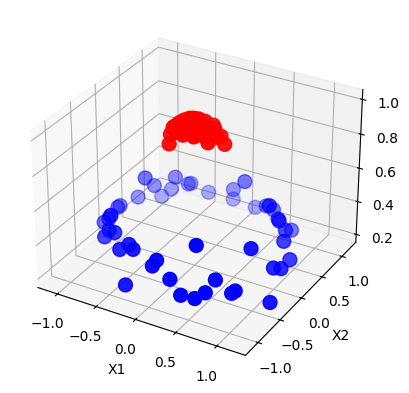

In [24]:
plot_3d_plot(X,y)

In [25]:
rbf_classifier = SVC(kernel="rbf")
rbf_classifier.fit(X_train, y_train)
y_pred = rbf_classifier.predict(X_test)

In [26]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_9614/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


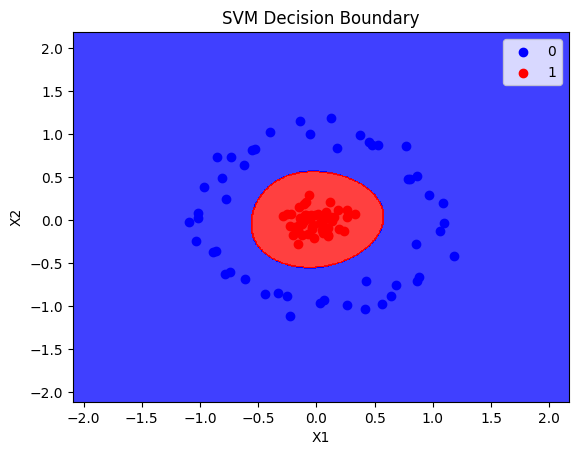

In [27]:
plot_decision_boundary(X, y, rbf_classifier)

In [28]:
poly_classifier = SVC(kernel="poly",degree=2)
poly_classifier.fit(X_train, y_train)
y_pred = poly_classifier.predict(X_test)

In [29]:
accuracy_score(y_test, y_pred)

1.0

/tmp/ipykernel_9614/3603277588.py:18: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


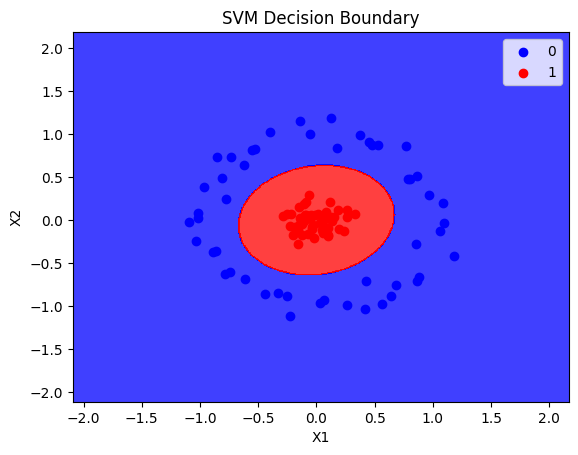

In [30]:
plot_decision_boundary(X, y, poly_classifier)